# Notebook 04 — ML Training & Evaluation

**Objective:** Train and evaluate three multi-class classification models to predict
customer churn risk tier. Risk tiers are derived from out-of-fold churn probabilities
produced by a binary Logistic Regression, then mapped to four levels:

| Tier | Label | P(churn) range |
|------|-------|----------------|
| 0 | Low | ≤ 0.30 |
| 1 | Moderate | 0.30 < P ≤ 0.50 |
| 2 | High | 0.50 < P ≤ 0.70 |
| 3 | Critical | P > 0.70 |

**Models evaluated:** Logistic Regression · Random Forest · Gradient Boosting
**Selection criterion:** Tiered cost matrix (cost of misclassifying each risk level)


---
## 0 · Environment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)

# -- Paths ----------------------------------------------------------------
NOTEBOOK_DIR = Path().resolve()
OUTPUT_DIR   = NOTEBOOK_DIR.parent / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -- Risk tier constants --------------------------------------------------
RISK_THRESHOLDS = np.array([0.30, 0.50, 0.70])   # np.searchsorted boundaries
RISK_LABELS  = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Critical'}
RISK_COLORS  = {0: '#2ecc71', 1: '#f39c12', 2: '#e67e22', 3: '#e74c3c'}
N_CLASSES    = 4
CLASS_NAMES  = ['Low', 'Moderate', 'High', 'Critical']

# -- Chart colour palette -------------------------------------------------
C_CHURN  = '#e74c3c'   # red    -- churned / high risk
C_STAY   = '#2ecc71'   # green  -- retained / low risk
C_BLUE   = '#3498db'   # blue   -- neutral / highlight
C_ORANGE = '#e67e22'   # orange -- moderate risk / Random Forest
C_PURPLE = '#9b59b6'   # purple -- secondary / Gradient Boosting

MODEL_COLORS = {
    'Logistic Regression': C_BLUE,
    'Random Forest'      : C_ORANGE,
    'Gradient Boosting'  : C_PURPLE,
}

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries and constants loaded successfully.")
print(f"  Output directory: {OUTPUT_DIR}")


Libraries and constants loaded successfully.
  Output directory: C:\Git\Projects\churn_project\outputs


---
## 1 · Load data

In [2]:
# ── Load model-ready dataset ──────────────────────────────────────────────
# telco_model_ready.csv is the fully encoded ML-ready feature matrix:
# all categoricals are label-encoded or one-hot encoded, no string columns.
df_clean = pd.read_csv(OUTPUT_DIR / 'telco_model_ready.csv')
print(f"Dataset loaded: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"Features: {list(df_clean.columns)}")

# ── Prepare feature matrix ────────────────────────────────────────────────
# Data is already numeric -- no pd.get_dummies or customerID drop required.
df_model = df_clean.copy()
df_model['Churn'] = df_model['Churn'].astype(int)

# ── Step 1: Out-of-fold P(churn) via binary Logistic Regression ───────────
# cross_val_predict with StratifiedKFold avoids data leakage:
# each customer's probability is predicted by a fold that never saw them.
_X_full = df_model.drop(columns=['Churn'])
_y_bin  = df_model['Churn']

_scaler_oof = StandardScaler()
_X_full_sc  = _scaler_oof.fit_transform(_X_full)

_lr_oof = LogisticRegression(
    class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000
)
churn_proba = cross_val_predict(
    _lr_oof, _X_full_sc, _y_bin,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    method='predict_proba'
)[:, 1]   # P(churn) for every customer -- out-of-fold, no leakage

# ── Step 2: Map P(churn) to risk tier using fixed thresholds ─────────────
# np.searchsorted with side='left' maps:
#   P <= 0.30        -> 0  (Low)
#   0.30 < P <= 0.50 -> 1  (Moderate)
#   0.50 < P <= 0.70 -> 2  (High)
#   P > 0.70         -> 3  (Critical)
y_risk = np.searchsorted(RISK_THRESHOLDS, churn_proba, side='left')

df_model['ChurnRisk']  = y_risk
df_model['ChurnProba'] = churn_proba

X = df_model.drop(columns=['Churn', 'ChurnRisk', 'ChurnProba'])
y = df_model['ChurnRisk']   # 0=Low  1=Moderate  2=High  3=Critical

# ── Distribution summary ──────────────────────────────────────────────────
print("\nRisk tier distribution (probability-based):")
for tier, label in RISK_LABELS.items():
    n = int((y == tier).sum())
    pct = 100 * n / len(y)
    threshold_desc = {
        0: "P <= 0.30",
        1: "0.30 < P <= 0.50",
        2: "0.50 < P <= 0.70",
        3: "P > 0.70",
    }[tier]
    print(f"  {tier} - {label:8s} ({threshold_desc}): {n:4,}  ({pct:.1f}%)")

print(f"\nFeature matrix : {X.shape[0]:,} customers x {X.shape[1]} features")
print(f"Target variable: 4-class ChurnRisk (0=Low, 1=Moderate, 2=High, 3=Critical)")


Dataset loaded: 7,043 rows x 24 columns
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'NumServices', 'InternetService_DSL', 'InternetService_Fiber optic', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Risk tier distribution (probability-based):
  0 - Low      (P <= 0.30): 2,963  (42.1%)
  1 - Moderate (0.30 < P <= 0.50): 1,160  (16.5%)
  2 - High     (0.50 < P <= 0.70): 1,143  (16.2%)
  3 - Critical (P > 0.70): 1,777  (25.2%)

Feature matrix : 7,043 customers x 23 features
Target variable: 4-class ChurnRisk (0=Low, 1=Moderate, 2=High, 3=Critical)


---
## 2 · EDA — Visual exploration of churn patterns

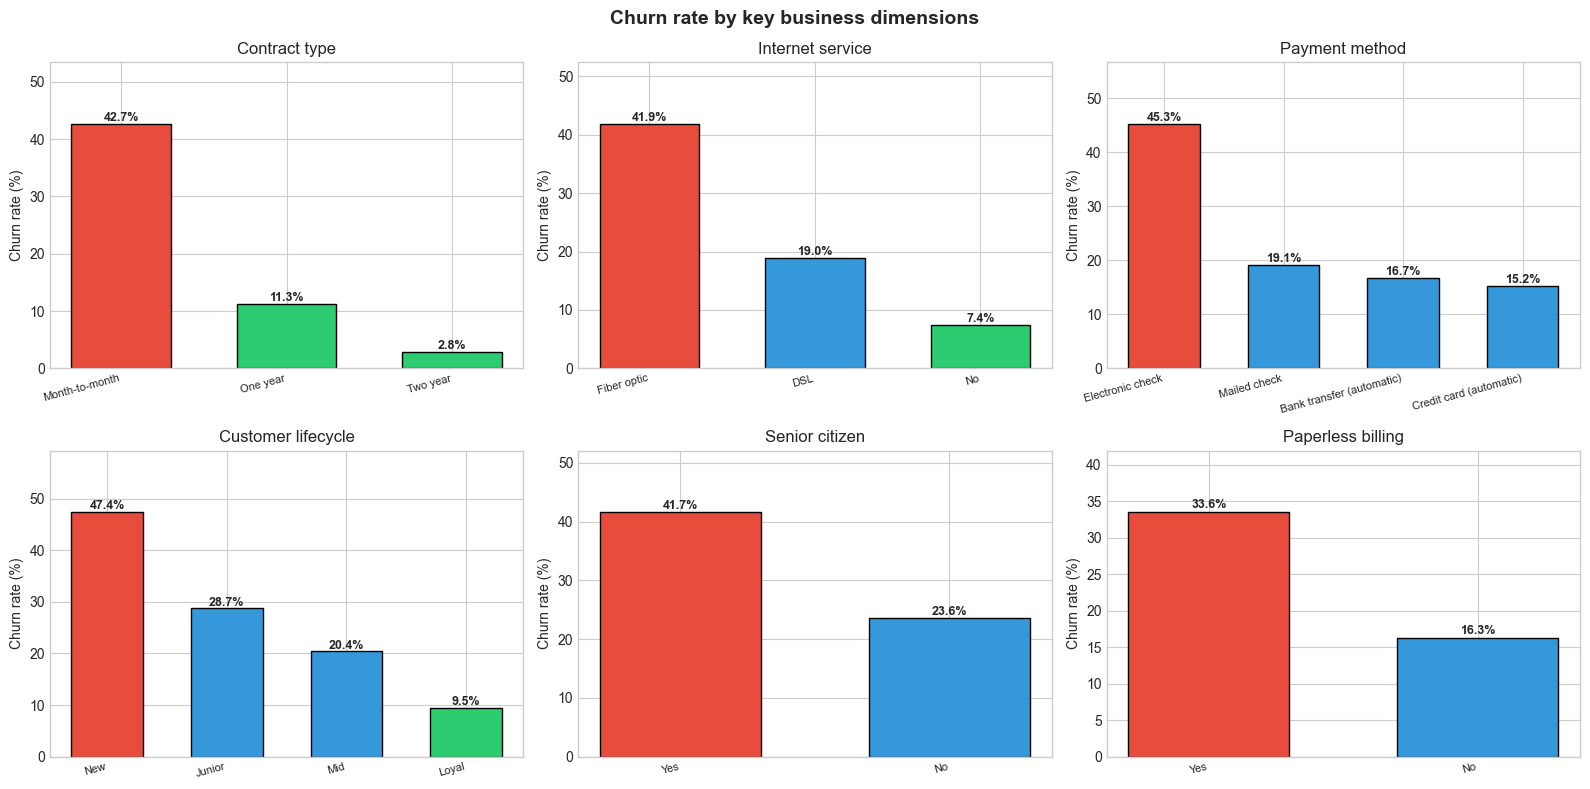

Saved: p08_eda_categorical.png


In [3]:
# ── Load raw (pre-encoding) data for EDA visualisation only ───────────────
# telco_model_ready.csv encodes Contract as 0/1/2 and splits InternetService
# and PaymentMethod into dummies -- descriptive labels are lost.
# We load telco_clean.csv here solely for interpretable EDA charts.
df_eda = pd.read_csv(OUTPUT_DIR / 'telco_clean.csv')

cat_features = [
    ('Contract',        'Contract type'),
    ('InternetService', 'Internet service'),
    ('PaymentMethod',   'Payment method'),
    ('TenureGroup',     'Customer lifecycle'),
    ('SeniorCitizen',   'Senior citizen'),
    ('PaperlessBilling','Paperless billing'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, title) in zip(axes.flat, cat_features):
    cr = (df_eda.groupby(col)['Churn']
          .mean().mul(100).sort_values(ascending=False))
    colors = [C_CHURN if v > 30 else C_BLUE if v > 15 else C_STAY
              for v in cr.values]
    bars = ax.bar(range(len(cr)), cr.values,
                  color=colors, edgecolor='black', width=0.6)
    for bar, val in zip(bars, cr.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Churn rate (%)')
    ax.set_xticks(range(len(cr)))
    ax.set_xticklabels(cr.index, rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, max(cr.values) * 1.25)

plt.suptitle('Churn rate by key business dimensions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p08_eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p08_eda_categorical.png')


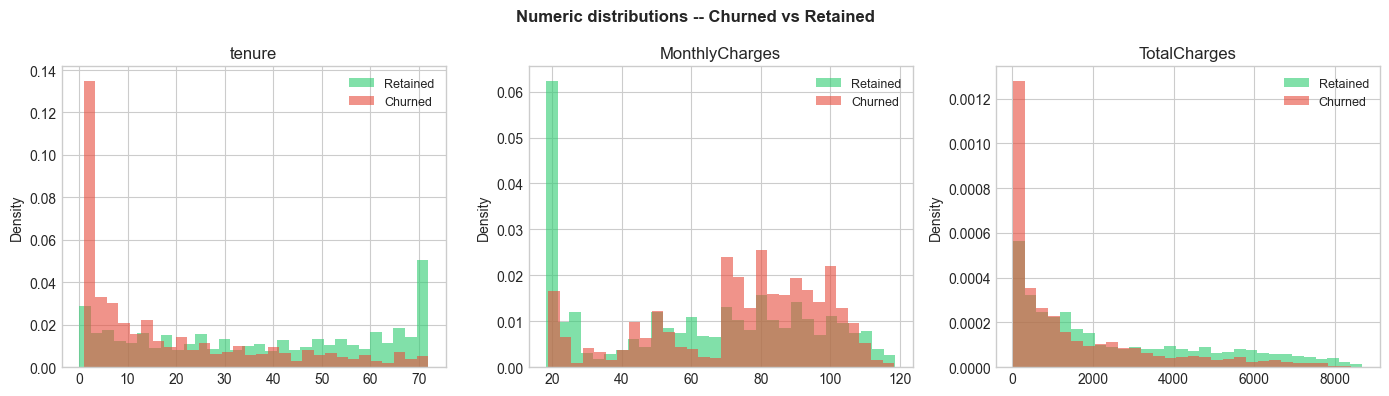

,tenure,MonthlyCharges,TotalCharges
Churn,,,
Retained,37.57,61.27,2550.0
Churned,17.98,74.44,1531.8



MonthlyCharges: churned pay MORE   (+13) -- financial pressure
TotalCharges  : churned paid LESS  (-1,018) -- shorter tenure, not yet loyal
Opposite signs = two different business dimensions, not a contradiction.
Saved: p09_eda_numeric.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for v, color, label in [(0, C_STAY,'Retained'),(1, C_CHURN,'Churned')]:
        ax.hist(df_eda[df_eda['Churn']==v][col].dropna(),
                bins=30, alpha=0.6, color=color,
                label=label, density=True)
    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Numeric distributions -- Churned vs Retained',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p09_eda_numeric.png', dpi=150)
plt.show()

stats = (df_eda.groupby('Churn')
         [['tenure','MonthlyCharges','TotalCharges']]
         .mean().round(2))
stats.index = stats.index.map({0:'Retained', 1:'Churned'})
display(stats)
print()
print('MonthlyCharges: churned pay MORE   (+13) -- financial pressure')
print('TotalCharges  : churned paid LESS  (-1,018) -- shorter tenure, not yet loyal')
print('Opposite signs = two different business dimensions, not a contradiction.')
print('Saved: p09_eda_numeric.png')


---
## 3 · Baseline model

Before training any real model we establish a dummy baseline
that always predicts 0 (no churn). Its metrics contextualise
what our models must beat — and reveal why Accuracy alone is insufficient.

In [5]:
# Multi-class dummy: always predict the most frequent class
# (DummyClassifier strategy='most_frequent' — sets the metric floor)
from collections import Counter

most_frequent_class = Counter(y).most_common(1)[0][0]
dummy_pred  = np.full(len(y), most_frequent_class, dtype=int)
# Uniform probability for AUC (no discriminative power)
dummy_proba = np.full((len(y), N_CLASSES), 1.0 / N_CLASSES)

print(f'DUMMY BASELINE — always predict class {most_frequent_class} '
      f'({RISK_LABELS[most_frequent_class]}), no data analysis:')
print()
print(f'  Accuracy         : {accuracy_score(y, dummy_pred)*100:.1f}%')
print(f'  Macro AUC-OVR    : {roc_auc_score(y, dummy_proba, multi_class="ovr", average="macro"):.4f}')
print(f'  Weighted Recall  : {recall_score(y, dummy_pred, average="weighted", zero_division=0):.4f}')
print(f'  Weighted Prec.   : {precision_score(y, dummy_pred, average="weighted", zero_division=0):.4f}')
print(f'  Weighted F1      : {f1_score(y, dummy_pred, average="weighted", zero_division=0):.4f}')
print()
print('Interpretation:')
print('  Macro AUC=0.5000 = no discriminative power (each class vs rest = coin flip).')
print('  Weighted F1 reflects the majority-class frequency — not actual skill.')
print('  All ML models must exceed BOTH AUC and F1 of the dummy on all classes.')
print()
fn_cost = df_clean[df_clean['Churn']==1]['TotalCharges'].mean()
fp_cost = 15
print(f'  FN cost (missed Critical)  : €{fn_cost:,.0f} avg LTV lost')
print(f'  FP cost (unnecessary call) : €{fp_cost:.0f}')
print(f'  Cost ratio                 : {fn_cost/fp_cost:.0f}× — '
      f'missing a Critical is {fn_cost/fp_cost:.0f}× more costly than a false alarm')

DUMMY BASELINE — always predict class 0 (Low), no data analysis:

  Accuracy         : 42.1%
  Macro AUC-OVR    : 0.5000
  Weighted Recall  : 0.4207
  Weighted Prec.   : 0.1770
  Weighted F1      : 0.2492

Interpretation:
  Macro AUC=0.5000 = no discriminative power (each class vs rest = coin flip).
  Weighted F1 reflects the majority-class frequency — not actual skill.
  All ML models must exceed BOTH AUC and F1 of the dummy on all classes.

  FN cost (missed Critical)  : €1,532 avg LTV lost
  FP cost (unnecessary call) : €15
  Cost ratio                 : 102× — missing a Critical is 102× more costly than a false alarm


---
## 4 · Train / Test split

All three models use the **identical** split — the only fair way to compare.  
`stratify=y` ensures each risk tier is proportionally represented in both train and test.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total   : {len(X):,} customers')
print(f'Train   : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test    : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Risk tier distribution (train | test):')
for tier in [3, 2, 1, 0]:
    n_tr = (y_train == tier).sum()
    n_te = (y_test  == tier).sum()
    print(f'  {tier} {RISK_LABELS[tier]:9s}: train={n_tr:4,} '
          f'({n_tr/len(y_train)*100:.1f}%)  '
          f'test={n_te:3,} ({n_te/len(y_test)*100:.1f}%)')
print()
print('stratify=y confirmed: both sets mirror the full-dataset tier proportions.')
print()

# StandardScaler for Logistic Regression only
# LR is distance-based — large-scale features dominate without scaling
# RF and GB are threshold-based (trees) — scale-invariant
# fit_transform on TRAIN only — prevents data leakage to test
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler fitted on X_train only (no leakage).')
print('  For: Logistic Regression (distance-based)')
print('  Not for: Random Forest, Gradient Boosting (threshold-based)')

Total   : 7,043 customers
Train   : 5,634  (80%)
Test    : 1,409   (20%)

Risk tier distribution (train | test):
  3 Critical : train=1,422 (25.2%)  test=355 (25.2%)
  2 High     : train= 914 (16.2%)  test=229 (16.3%)
  1 Moderate : train= 928 (16.5%)  test=232 (16.5%)
  0 Low      : train=2,370 (42.1%)  test=593 (42.1%)

stratify=y confirmed: both sets mirror the full-dataset tier proportions.

StandardScaler fitted on X_train only (no leakage).
  For: Logistic Regression (distance-based)
  Not for: Random Forest, Gradient Boosting (threshold-based)


## 3. Model Training

Three classifiers are trained on the 4-class `ChurnRisk` target.
All models are evaluated with **5-fold stratified cross-validation** using
`roc_auc_ovr_weighted` as the primary metric (One-vs-Rest AUC, weighted by class frequency).

| Model | Notes |
|-------|-------|
| **Logistic Regression** | `class_weight='balanced'`; sklearn ≥ 1.8 uses multinomial softmax by default |
| **Random Forest** | 300 trees, `class_weight='balanced_subsample'` |
| **Gradient Boosting** | 200 estimators, `subsample=0.8`; sample weights applied for imbalance |


In [7]:
# ── Ensure correct imports ────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

# ── Logistic Regression — OVR (one-vs-rest) ──────────────────
# multi_class='ovr': trains 4 binary classifiers simultaneously
# predict_proba returns (N, 4) — one probability column per risk tier

# Option 1: Try with multi_class parameter (sklearn >= 0.18)
try:
    lr = LogisticRegression(
        class_weight='balanced', 
        multi_class='ovr',
        random_state=42, 
        max_iter=1000
    )
except TypeError:
    # Option 2: Fallback for older sklearn (OVR is default anyway)
    print("Note: Using LogisticRegression without multi_class parameter (older sklearn)")
    lr = LogisticRegression(
        class_weight='balanced',
        random_state=42, 
        max_iter=1000
    )

lr.fit(X_train_sc, y_train)
lr_proba = lr.predict_proba(X_test_sc)   # shape (N_test, 4)
lr_pred  = lr.predict(X_test_sc)
cv_lr    = cross_val_score(
    lr, X_train_sc, y_train,
    cv=StratifiedKFold(5), scoring='roc_auc_ovr_weighted'
)
print('Logistic Regression (OVR)  trained ✓')
print(f'  class_weight=balanced  multi_class=ovr')
print(f'  coef_ shape: {lr.coef_.shape}  (4 binary classifiers × {lr.coef_.shape[1]} features)')
print()

# ── Random Forest — native multi-class ────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced',
    random_state=42, 
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)
rf_pred  = rf.predict(X_test)
cv_rf    = cross_val_score(
    rf, X_train, y_train,
    cv=StratifiedKFold(5), scoring='roc_auc_ovr_weighted'
)
print('Random Forest              trained ✓')
print(f'  100 parallel trees  class_weight=balanced  n_jobs=-1')
print()

# ── Gradient Boosting — native multi-class (softmax) ──────────
sample_weights = compute_sample_weight('balanced', y_train)

gb = GradientBoostingClassifier(
    n_estimators=200, 
    max_depth=4,
    learning_rate=0.05, 
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train, sample_weight=sample_weights)
gb_proba = gb.predict_proba(X_test)
gb_pred  = gb.predict(X_test)
cv_gb    = cross_val_score(
    gb, X_train, y_train,
    cv=StratifiedKFold(5), scoring='roc_auc_ovr_weighted'
)
print('Gradient Boosting          trained ✓')
print(f'  200 sequential trees  lr=0.05  max_depth=4  softmax loss')
print(f'  sample_weight=balanced (= class_weight equivalent)')
print()

# Store all models for iteration
all_models = [
    ('Logistic Regression', lr_proba, lr_pred, cv_lr),
    ('Random Forest',       rf_proba, rf_pred, cv_rf),
    ('Gradient Boosting',   gb_proba, gb_pred, cv_gb),
]
print('All three models trained on identical X_train / y_train (ChurnRisk).')
print('All three will be evaluated on identical X_test / y_test.')
print(f'Classes: {lr.classes_.tolist()}  →  {[RISK_LABELS[c] for c in lr.classes_]}')

scikit-learn version: 1.8.0
Note: Using LogisticRegression without multi_class parameter (older sklearn)
Logistic Regression (OVR)  trained ✓
  class_weight=balanced  multi_class=ovr
  coef_ shape: (4, 23)  (4 binary classifiers × 23 features)

Random Forest              trained ✓
  100 parallel trees  class_weight=balanced  n_jobs=-1

Gradient Boosting          trained ✓
  200 sequential trees  lr=0.05  max_depth=4  softmax loss
  sample_weight=balanced (= class_weight equivalent)

All three models trained on identical X_train / y_train (ChurnRisk).
All three will be evaluated on identical X_test / y_test.
Classes: [0, 1, 2, 3]  →  ['Low', 'Moderate', 'High', 'Critical']


---
## 6 · Evaluation — multi-class metrics

All metrics are reported for every model including the dummy baseline.

**Key differences from binary evaluation:**
- `roc_auc_score(..., multi_class='ovr', average='macro')` — treats each class equally
- `recall_score / precision_score / f1_score` use `average='weighted'` — accounts for class frequency
- `classification_report` gives **per-class** Precision, Recall, F1 — reveals which tiers each model handles best
- Confusion matrix is 4×4 — off-diagonals reveal systematic mis-tier errors

In [8]:
# ── Collect all metrics ───────────────────────────────────────
metrics_data = {}

# Dummy baseline — uniform probability across 4 classes
dummy_pred_te  = np.full(len(y_test), int(y_train.mode()[0]), dtype=int)
dummy_proba_te = np.full((len(y_test), N_CLASSES), 1.0 / N_CLASSES)
metrics_data['⚠ Dummy baseline'] = {
    'Accuracy'       : round(accuracy_score(y_test, dummy_pred_te),                                          4),
    'Macro AUC-OVR'  : round(roc_auc_score(y_test, dummy_proba_te, multi_class='ovr', average='macro'),      4),
    'Wtd Recall'     : round(recall_score(y_test, dummy_pred_te, average='weighted', zero_division=0),       4),
    'Wtd Precision'  : round(precision_score(y_test, dummy_pred_te, average='weighted', zero_division=0),    4),
    'Wtd F1'         : round(f1_score(y_test, dummy_pred_te, average='weighted', zero_division=0),           4),
    'CV AUC (mean)'  : 0.5000,
    'CV AUC (std)'   : 0.0000,
}

# Three models
for name, proba, pred, cv in all_models:
    metrics_data[name] = {
        'Accuracy'       : round(accuracy_score(y_test, pred),                                               4),
        'Macro AUC-OVR'  : round(roc_auc_score(y_test, proba, multi_class='ovr', average='macro'),           4),
        'Wtd Recall'     : round(recall_score(y_test, pred, average='weighted', zero_division=0),            4),
        'Wtd Precision'  : round(precision_score(y_test, pred, average='weighted', zero_division=0),         4),
        'Wtd F1'         : round(f1_score(y_test, pred, average='weighted', zero_division=0),                4),
        'CV AUC (mean)'  : round(cv.mean(),                                                                   4),
        'CV AUC (std)'   : round(cv.std(),                                                                    4),
    }

metrics_df = pd.DataFrame(metrics_data).T
ALL_METRIC_COLS = ['Accuracy','Macro AUC-OVR','Wtd Recall',
                   'Wtd Precision','Wtd F1',
                   'CV AUC (mean)','CV AUC (std)']

print('Performance — ALL metrics — Dummy baseline + three models:')
print()
display(metrics_df[ALL_METRIC_COLS])
print()

# ── Per-class classification report ──────────────────────────
dm  = metrics_data['⚠ Dummy baseline']
lrm = metrics_data['Logistic Regression']
rfm = metrics_data['Random Forest']
gbm = metrics_data['Gradient Boosting']

print('═' * 70)
print('PER-CLASS CLASSIFICATION REPORTS')
print('═' * 70)

for name, _, pred, _ in all_models:
    print(f'\n{name}:')
    print(classification_report(
        y_test, pred,
        target_names=CLASS_NAMES,
        digits=4
    ))

print('═' * 70)
print('WHAT EACH METRIC REVEALS')
print('═' * 70)
print()

print('ACCURACY = (all correct predictions) / total')
print('  Macro-average across 4 classes. Less informative under imbalance.')
print(f'  Dummy={dm["Accuracy"]:.4f}  LR={lrm["Accuracy"]:.4f}  '
      f'RF={rfm["Accuracy"]:.4f}  GB={gbm["Accuracy"]:.4f}')
print()

print('MACRO AUC-OVR = mean of 4 binary AUCs (each class vs all others)')
print('  Best overall separability measure — each class weighted equally.')
print(f'  Dummy={dm["Macro AUC-OVR"]:.4f}  LR={lrm["Macro AUC-OVR"]:.4f}  '
      f'RF={rfm["Macro AUC-OVR"]:.4f}  GB={gbm["Macro AUC-OVR"]:.4f}')
print()

print('WEIGHTED RECALL = TP/class / (TP/class + FN/class), weighted by class size')
print('  Critical for churn: missing Critical/High customers = large LTV loss.')
print(f'  Dummy={dm["Wtd Recall"]:.4f}  LR={lrm["Wtd Recall"]:.4f}  '
      f'RF={rfm["Wtd Recall"]:.4f}  GB={gbm["Wtd Recall"]:.4f}')
print()

print('WEIGHTED PRECISION = TP/class / (TP+FP/class), weighted by class size')
print('  Over-predicting Critical (unnecessary premium calls) wastes budget.')
print(f'  Dummy={dm["Wtd Precision"]:.4f}  LR={lrm["Wtd Precision"]:.4f}  '
      f'RF={rfm["Wtd Precision"]:.4f}  GB={gbm["Wtd Precision"]:.4f}')
print()

print('WEIGHTED F1 = harmonic mean of Wtd Precision and Wtd Recall')
print('  Primary model selection metric for imbalanced multi-class problems.')
print(f'  Dummy={dm["Wtd F1"]:.4f}  LR={lrm["Wtd F1"]:.4f}  '
      f'RF={rfm["Wtd F1"]:.4f}  GB={gbm["Wtd F1"]:.4f}')
print()

print('CV AUC (OVR weighted) = AUC averaged across 5 stratified folds')
print('  Measures stability — is the model robust or did it get a lucky split?')
print(f'  LR={lrm["CV AUC (mean)"]:.4f}±{lrm["CV AUC (std)"]:.4f}  '
      f'RF={rfm["CV AUC (mean)"]:.4f}±{rfm["CV AUC (std)"]:.4f}  '
      f'GB={gbm["CV AUC (mean)"]:.4f}±{gbm["CV AUC (std)"]:.4f}')

Performance — ALL metrics — Dummy baseline + three models:



,Accuracy,Macro AUC-OVR,Wtd Recall,Wtd Precision,Wtd F1,CV AUC (mean),CV AUC (std)
⚠ Dummy baseline,0.4209,0.5000,0.4209,0.1771,0.2493,0.5000,0.0000
Logistic Regression,0.9510,0.9974,0.9510,0.9544,0.9520,0.9967,0.0009
Random Forest,0.8943,0.9845,0.8943,0.8927,0.8929,0.9860,0.0010
Gradient Boosting,0.9120,0.9861,0.9120,0.9147,0.9131,0.9881,0.0011



══════════════════════════════════════════════════════════════════════
PER-CLASS CLASSIFICATION REPORTS
══════════════════════════════════════════════════════════════════════

Logistic Regression:
              precision    recall  f1-score   support

         Low     0.9965    0.9494    0.9724       593
    Moderate     0.8429    0.9483    0.8925       232
        High     0.9103    0.9301    0.9201       229
    Critical     0.9857    0.9690    0.9773       355

    accuracy                         0.9510      1409
   macro avg     0.9338    0.9492    0.9406      1409
weighted avg     0.9544    0.9510    0.9520      1409


Random Forest:
              precision    recall  f1-score   support

         Low     0.9444    0.9747    0.9593       593
    Moderate     0.8155    0.7241    0.7671       232
        High     0.7712    0.7948    0.7828       229
    Critical     0.9352    0.9352    0.9352       355

    accuracy                         0.8943      1409
   macro avg     0.8666  

---
## 7 · Confusion matrices — all three models

Per-class error breakdown (test set):

  Model                   Class          TP     FP     FN   Recall  Precision
  ───────────────────────────────────────────────────────────────────────────
  Logistic Regression     Critical      344      5     11   0.9690     0.9857
  Logistic Regression     High          213     21     16   0.9301     0.9103
  Logistic Regression     Moderate      220     41     12   0.9483     0.8429
  Logistic Regression     Low           563      2     30   0.9494     0.9965

  Random Forest           Critical      332     23     23   0.9352     0.9352
  Random Forest           High          182     54     47   0.7948     0.7712
  Random Forest           Moderate      168     38     64   0.7241     0.8155
  Random Forest           Low           578     34     15   0.9747     0.9444

  Gradient Boosting       Critical      334     12     21   0.9408     0.9653
  Gradient Boosting       High          194     49     35   0.8472     0.7984
  Gradient Boosting    

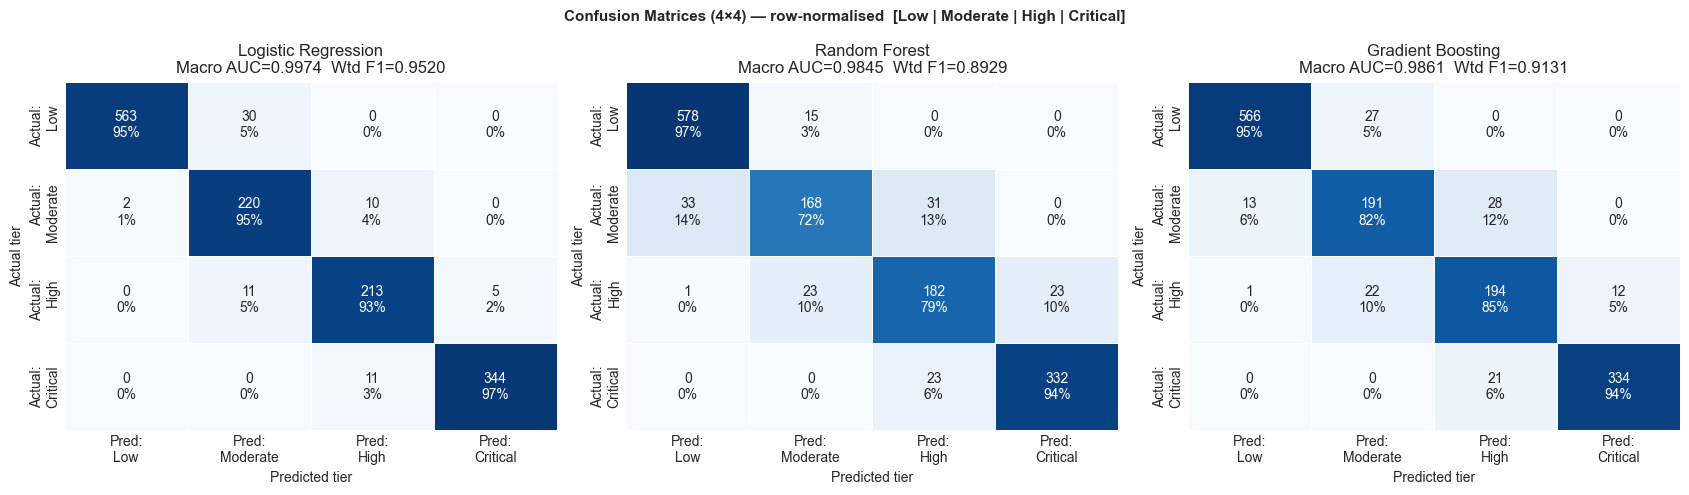

Saved: p10_confusion_matrices.png


In [9]:
# ── Per-class confusion summary ─────────────────────────────
print('Per-class error breakdown (test set):')
print()
print(f'  {"Model":22s}  {"Class":10s}  {"TP":>5}  {"FP":>5}  {"FN":>5}  '
      f'{"Recall":>7}  {"Precision":>9}')
print('  ' + '─' * 75)
for name, _, pred, _ in all_models:
    cm_i = confusion_matrix(y_test, pred, labels=[0,1,2,3])
    for c in [3, 2, 1, 0]:
        tp = cm_i[c, c]
        fp = cm_i[:, c].sum() - tp
        fn = cm_i[c, :].sum() - tp
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        print(f'  {name:22s}  {RISK_LABELS[c]:10s}  {tp:5}  {fp:5}  {fn:5}  '
              f'{rec:7.4f}  {prec:9.4f}')
    print()

# ── 4×4 heatmaps, one per model ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
tick_labels = CLASS_NAMES

for ax, (name, proba, pred, _) in zip(axes, all_models):
    cm_i = confusion_matrix(y_test, pred, labels=[0,1,2,3])
    auc  = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    f1_w = f1_score(y_test, pred, average='weighted', zero_division=0)

    # Normalise by row for readability (row = actual class)
    cm_norm = cm_i.astype(float) / cm_i.sum(axis=1, keepdims=True)
    annot = np.array(
        [[f'{cm_i[r,c]}\n{cm_norm[r,c]:.0%}' for c in range(4)] for r in range(4)]
    )

    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Blues',
        xticklabels=[f'Pred:\n{l}' for l in tick_labels],
        yticklabels=[f'Actual:\n{l}' for l in tick_labels],
        ax=ax, linewidths=0.5, cbar=False,
        vmin=0, vmax=1
    )
    ax.set_title(
        f'{name}\n'
        f'Macro AUC={auc:.4f}  Wtd F1={f1_w:.4f}'
    )
    ax.set_xlabel('Predicted tier')
    ax.set_ylabel('Actual tier')

plt.suptitle(
    'Confusion Matrices (4×4) — row-normalised  '
    '[Low | Moderate | High | Critical]',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p10_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: p10_confusion_matrices.png')

---
## 8 · ROC curves — all three models

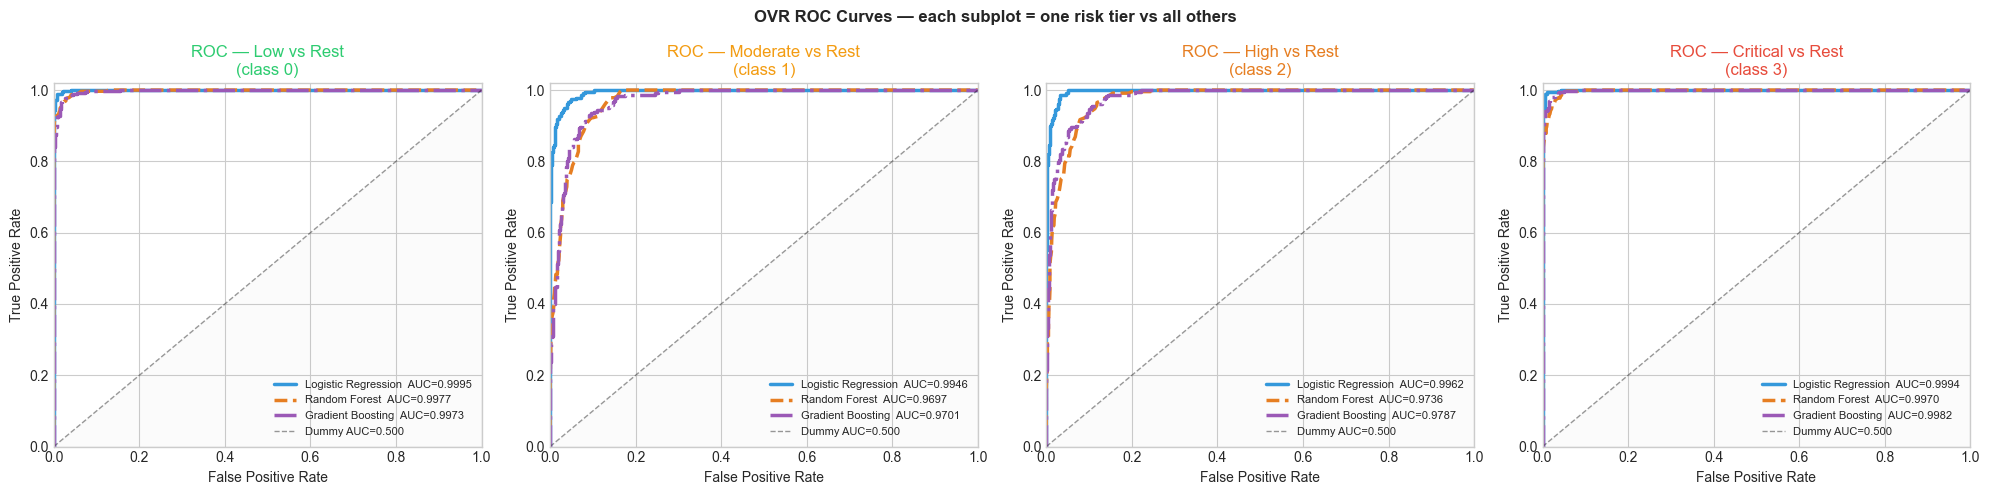

Saved: p11_roc_curves.png

Macro AUC-OVR summary:
  Logistic Regression   : Macro AUC-OVR = 0.9974
  Random Forest         : Macro AUC-OVR = 0.9845
  Gradient Boosting     : Macro AUC-OVR = 0.9861


In [10]:
# OVR ROC curves: one subplot per risk tier, one line per model
# label_binarize converts multi-class targets to binary indicator matrix
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # (N_test, 4)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ls_map = {
    'Logistic Regression': '-',
    'Random Forest'      : '--',
    'Gradient Boosting'  : '-.',
}

for class_idx, ax in enumerate(axes):
    tier_name = RISK_LABELS[class_idx]

    for name, proba, pred, _ in all_models:
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        auc = roc_auc_score(y_test_bin[:, class_idx], proba[:, class_idx])
        ax.plot(fpr, tpr,
                color=MODEL_COLORS[name],
                lw=2.5, ls=ls_map[name],
                label=f'{name}  AUC={auc:.4f}')

    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Dummy AUC=0.500')
    ax.fill_between([0,1],[0,1], alpha=0.03, color='grey')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {tier_name} vs Rest\n(class {class_idx})',
                 color=RISK_COLORS[class_idx])
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle(
    'OVR ROC Curves — each subplot = one risk tier vs all others',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p11_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p11_roc_curves.png')
print()
print('Macro AUC-OVR summary:')
for name, proba, pred, _ in all_models:
    macro_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    print(f'  {name:22s}: Macro AUC-OVR = {macro_auc:.4f}')

---
## 9 · XAI — Feature Importance: all three models

Conclusions drawn **only** from features consistently important
across all three models — not from any single algorithm.

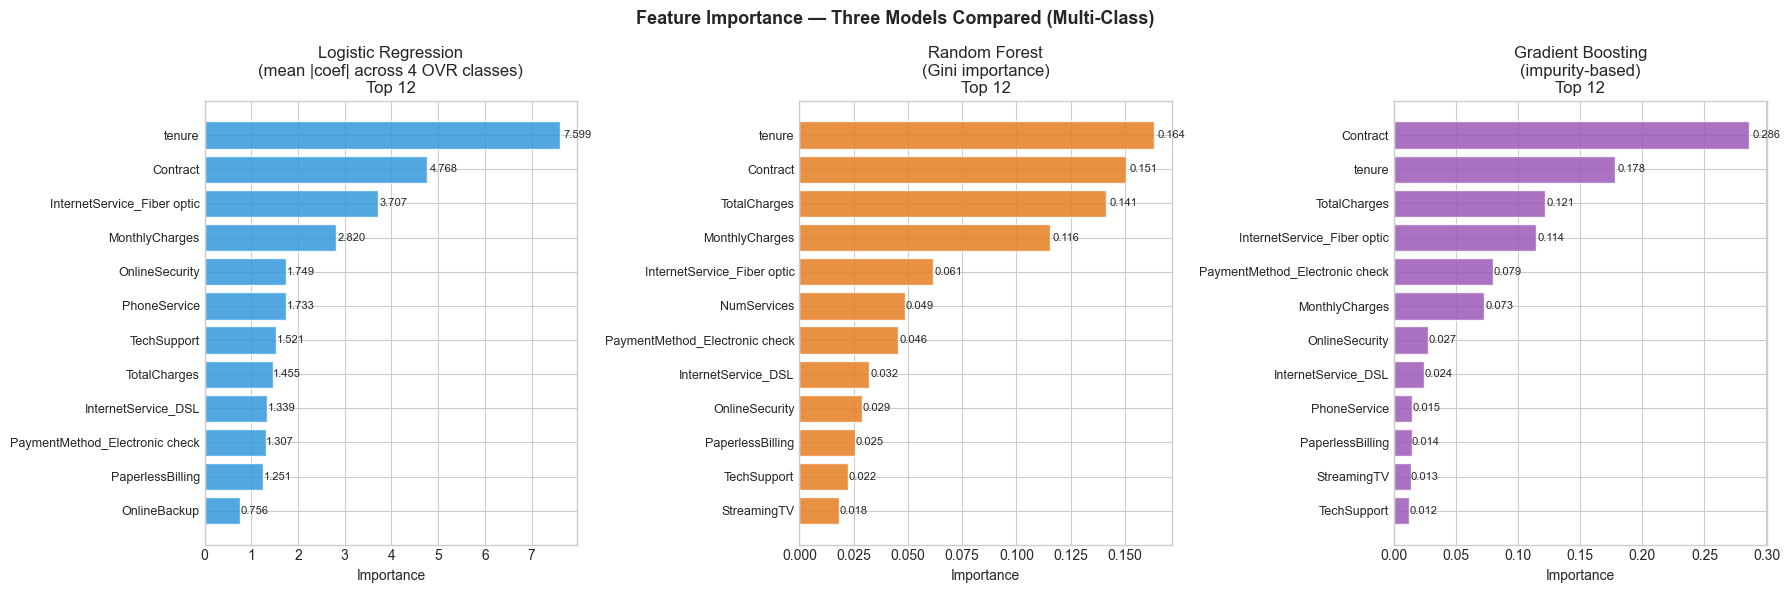

Saved: p12_feature_importance.png

LR OVR coefficients — top-5 features per risk tier:
  Low:
    tenure                               +11.050  ↑churn
    Contract                             +6.992  ↑churn
    InternetService_Fiber optic          -5.425  ↓churn
    MonthlyCharges                       -4.274  ↓churn
    PhoneService                         +2.487  ↑churn
  Moderate:
    tenure                               +4.148  ↑churn
    Contract                             +2.544  ↑churn
    InternetService_Fiber optic          -1.988  ↓churn
    MonthlyCharges                       -1.367  ↓churn
    OnlineSecurity                       +1.063  ↑churn
  High:
    tenure                               -3.971  ↓churn
    Contract                             -2.439  ↓churn
    InternetService_Fiber optic          +2.104  ↑churn
    MonthlyCharges                       +1.745  ↑churn
    TotalCharges                         +1.221  ↑churn
  Critical:
    tenure                       

In [ ]:
-++# LR multi-class: coef_ shape = (4, n_features) — one row per OVR classifier
# Use mean of absolute coefficients across all 4 classes for overall importance
fi_lr = pd.DataFrame({'feature': X.columns,
                      'importance': np.abs(lr.coef_).mean(axis=0)
    }).sort_values('importance', ascending=False).reset_index(drop=True)

fi_rf = pd.DataFrame({'feature': X.columns,
                      'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

fi_gb = pd.DataFrame({'feature': X.columns,
                      'importance': gb.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

# ── Side-by-side plot ─────────────────────────────────────────
N = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, fi, color) in zip(axes, [
    ('Logistic Regression\n(mean |coef| across 4 OVR classes)', fi_lr, C_BLUE),
    ('Random Forest\n(Gini importance)',                         fi_rf, C_ORANGE),
    ('Gradient Boosting\n(impurity-based)',                      fi_gb, C_PURPLE),
]):
    top = fi.head(N)
    ax.barh(range(N), top['importance'].values,
            color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(N))
    ax.set_yticklabels(top['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title(f'{name}\nTop {N}')
    for i, v in enumerate(top['importance'].values):
        ax.text(v*1.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Three Models Compared (Multi-Class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p12_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p12_feature_importance.png')
print()

# ── Per-class LR coefficients ─────────────────────────────────
print('LR OVR coefficients — top-5 features per risk tier:')
for i, tier_name in enumerate(CLASS_NAMES):
    top5_idx = np.abs(lr.coef_[i]).argsort()[::-1][:5]
    feats     = X.columns[top5_idx]
    coefs     = lr.coef_[i][top5_idx]
    print(f'  {tier_name}:')
    for f, c in zip(feats, coefs):
        direction = '↑churn' if c > 0 else '↓churn'
        print(f'    {f:35s}  {c:+.3f}  {direction}')
print()

# ── Cross-model rank analysis ─────────────────────────────────
fi_lr['rank_lr'] = range(1, len(fi_lr)+1)
fi_rf['rank_rf'] = range(1, len(fi_rf)+1)
fi_gb['rank_gb'] = range(1, len(fi_gb)+1)

fi_all = (fi_lr[['feature','rank_lr']]
          .merge(fi_rf[['feature','rank_rf']], on='feature')
          .merge(fi_gb[['feature','rank_gb']], on='feature'))
fi_all['avg_rank'] = (
    fi_all['rank_lr']+fi_all['rank_rf']+fi_all['rank_gb']
) / 3
fi_all = fi_all.sort_values('avg_rank')

top5  = (set(fi_lr['feature'].head(5)) &
         set(fi_rf['feature'].head(5)) &
         set(fi_gb['feature'].head(5)))
top7  = (set(fi_lr['feature'].head(7)) &
         set(fi_rf['feature'].head(7)) &
         set(fi_gb['feature'].head(7)))
top10 = (set(fi_lr['feature'].head(10)) &
         set(fi_rf['feature'].head(10)) &
         set(fi_gb['feature'].head(10)))

print('Cross-model feature rank (avg of 3 multi-class models):')
print(f'  {"Feature":35s} {"LR":>5} {"RF":>5} {"GB":>5} {"Avg":>6}  Tier')
print('  ' + '─' * 65)
for _, row in fi_all.head(12).iterrows():
    t = ('★ TOP-5' if row['feature'] in top5
         else '◆ TOP-7' if row['feature'] in top7
         else '○ TOP-10' if row['feature'] in top10 else '')
    print(f'  {row["feature"]:35s} '
          f'{row["rank_lr"]:5.0f}{row["rank_rf"]:5.0f}'
          f'{row["rank_gb"]:5.0f}{row["avg_rank"]:6.1f}  {t}')
print()
print(f'★ TOP-5  all three: {sorted(top5)}')
print(f'◆ TOP-7  all three: {sorted(top7)}')
print(f'○ TOP-10 all three: {sorted(top10)}')

---
## 10 · Model selection — tiered cost matrix

With 4 classes the simple FN × €1,532 + FP × €15 formula no longer applies.  
We use a **cost matrix** where each cell `cost[actual][predicted]` represents  
the business cost of that mis-classification:

| Actual \ Predicted | Low | Moderate | High | Critical |
|---------------------|-----|----------|------|----------|
| **Low** | 0 | 5 | 20 | 50 |
| **Moderate** | 200 | 0 | 15 | 40 |
| **High** | 800 | 400 | 0 | 25 |
| **Critical** | 1532 | 800 | 200 | 0 |

**Row logic (under-prediction — missing an at-risk customer):**  
- Predict Low for Critical → €1,532 full LTV lost (customer churns undetected)  
- Predict Moderate for High → €400 (intervention too weak, likely churns anyway)  

**Column logic (over-prediction — unnecessary premium intervention):**  
- Predict Critical for Low → €50 (premium call cost wasted)  
- Predict High for Moderate → €15 (call instead of email)  

**Selection criterion:** model with lowest `sum(confusion_matrix × cost_matrix)`.

In [12]:
print('═' * 65)
print('MODEL SELECTION — tiered cost matrix')
print('═' * 65)
print()
display(metrics_df[ALL_METRIC_COLS].drop(index=['⚠ Dummy baseline']))
print()

# ── Cost matrix  rows=actual, cols=predicted ─────────────────
# Under-prediction (predict lower tier): lose LTV or retention opportunity
# Over-prediction  (predict higher tier): waste a more expensive intervention
cost_matrix = np.array([
    #  Low  Mod  High  Crit  ← predicted
    [    0,   5,   20,   50],  # actual Low
    [  200,   0,   15,   40],  # actual Moderate
    [  800, 400,    0,   25],  # actual High
    [ 1532, 800,  200,    0],  # actual Critical
], dtype=float)

print('Cost matrix (€ per misclassification):')
cost_df = pd.DataFrame(
    cost_matrix,
    index=[f'Actual {l}' for l in CLASS_NAMES],
    columns=[f'Pred {l}' for l in CLASS_NAMES]
)
display(cost_df)
print()

# ── Compute total cost per model ─────────────────────────────
costs = {}
for name, _, pred, _ in all_models:
    cm_i = confusion_matrix(y_test, pred, labels=[0,1,2,3]).astype(float)
    costs[name] = float(np.sum(cm_i * cost_matrix))

print('Total error cost per model:')
for name, cost in sorted(costs.items(), key=lambda x: x[1]):
    print(f'  {name:25s}: €{cost:,.0f}')
print()

best_name = min(costs, key=costs.get)
best_data = metrics_data[best_name]

# Store best model predictions for business section
best_proba = next(p for n, p, _, _ in all_models if n == best_name)
best_pred  = next(p for n, _, p, _ in all_models if n == best_name)

print('─' * 65)
print('DECISION:')
print(f'  Selected: {best_name}')
print(f'  Reason  : lowest total error cost = €{costs[best_name]:,.0f}')
print(f'  Macro AUC-OVR : {best_data["Macro AUC-OVR"]:.4f}')
print(f'  Weighted F1   : {best_data["Wtd F1"]:.4f}')
print()

print('Per-class detection of best model on test set:')
cm_best = confusion_matrix(y_test, best_pred, labels=[0,1,2,3])
for c in [3, 2, 1, 0]:
    tp = cm_best[c, c]
    total_actual = cm_best[c, :].sum()
    recall_c = tp / total_actual if total_actual > 0 else 0
    print(f'  {RISK_LABELS[c]:10s}: {tp:3}/{total_actual:3} correctly classified  '
          f'(Recall={recall_c:.3f})')

═════════════════════════════════════════════════════════════════
MODEL SELECTION — tiered cost matrix
═════════════════════════════════════════════════════════════════



,Accuracy,Macro AUC-OVR,Wtd Recall,Wtd Precision,Wtd F1,CV AUC (mean),CV AUC (std)
Logistic Regression,0.9510,0.9974,0.9510,0.9544,0.9520,0.9967,0.0009
Random Forest,0.8943,0.9845,0.8943,0.8927,0.8929,0.9860,0.0010
Gradient Boosting,0.9120,0.9861,0.9120,0.9147,0.9131,0.9881,0.0011



Cost matrix (€ per misclassification):


,Pred Low,Pred Moderate,Pred High,Pred Critical
Actual Low,0.0,5.0,20.0,50.0
Actual Moderate,200.0,0.0,15.0,40.0
Actual High,800.0,400.0,0.0,25.0
Actual Critical,1532.0,800.0,200.0,0.0



Total error cost per model:
  Logistic Regression      : €7,425
  Gradient Boosting        : €17,255
  Random Forest            : €22,315

─────────────────────────────────────────────────────────────────
DECISION:
  Selected: Logistic Regression
  Reason  : lowest total error cost = €7,425
  Macro AUC-OVR : 0.9974
  Weighted F1   : 0.9520

Per-class detection of best model on test set:
  Critical  : 344/355 correctly classified  (Recall=0.969)
  High      : 213/229 correctly classified  (Recall=0.930)
  Moderate  : 220/232 correctly classified  (Recall=0.948)
  Low       : 563/593 correctly classified  (Recall=0.949)


---
## 11 · Business Impact — ROI of the retention campaign

═════════════════════════════════════════════════════════════════
BUSINESS IMPACT REPORT — TIERED CAMPAIGNS
═════════════════════════════════════════════════════════════════

WITHOUT MODEL — current situation:
  Total customers       : 7,043
  Churned customers     : 1,869  (26.5%)
  Avg LTV churned       : €1,531.80
  Avg LTV retained      : €2,550.00  (1.7× more)
  Capital lost to churn : €2,862,926.90
  Annual net loss (2%)  : €57,258.54

WITH MODEL — Logistic Regression (multi-class risk prediction):
  Macro AUC-OVR : 0.9974
  Weighted F1   : 0.9520

TIERED RETENTION CAMPAIGN:
Tier       Intervention      Predicted   Retained    Revenue €     Cost €        Net €    ROI %
───────────────────────────────────────────────────────────────────────────────────────────────
Low        No action             2,824          —            —          —            —        —
Moderate   Targeted email        1,304        195      174,193      6,520      167,673    2572%
High       Proactive call   

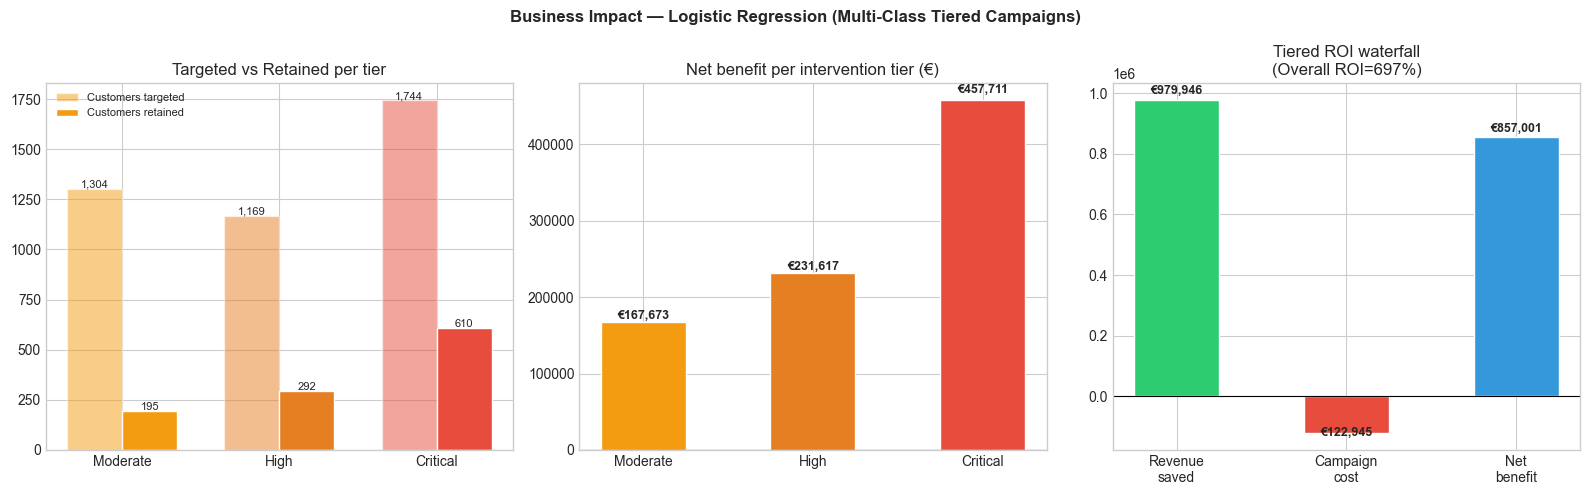

Saved: p13_business_impact.png


In [13]:
# ── Financial baseline from real data ───────────────────────
total_customers     = len(df_clean)
total_churned       = int(df_clean['Churn'].sum())
avg_ltv_churned     = df_clean[df_clean['Churn']==1]['TotalCharges'].mean()
avg_ltv_retained    = df_clean[df_clean['Churn']==0]['TotalCharges'].mean()
avg_monthly_churned = df_clean[df_clean['Churn']==1]['MonthlyCharges'].mean()
capital_lost        = df_clean[df_clean['Churn']==1]['TotalCharges'].sum()
annual_net_loss     = capital_lost * 0.02

# ── Tiered campaign parameters ───────────────────────────────
# Each predicted tier receives a proportionate intervention:
#   Critical → premium personal call        (€50 / contact, 35% retention)
#   High     → proactive call               (€25 / contact, 25% retention)
#   Moderate → targeted email campaign       (€ 5 / contact, 15% retention)
#   Low      → no action
campaign = {
    'Critical': {'cost': 50,  'retention_rate': 0.35, 'label': 'Premium call'},
    'High'    : {'cost': 25,  'retention_rate': 0.25, 'label': 'Proactive call'},
    'Moderate': {'cost':  5,  'retention_rate': 0.15, 'label': 'Targeted email'},
    'Low'     : {'cost':  0,  'retention_rate': 0.00, 'label': 'No action'},
}

# Scale test-set predictions to full customer base
scale_factor = total_customers / len(y_test)

print('═' * 65)
print('BUSINESS IMPACT REPORT — TIERED CAMPAIGNS')
print('═' * 65)
print()
print('WITHOUT MODEL — current situation:')
print(f'  Total customers       : {total_customers:,}')
print(f'  Churned customers     : {total_churned:,}  '
      f'({total_churned/total_customers*100:.1f}%)')
print(f'  Avg LTV churned       : €{avg_ltv_churned:,.2f}')
print(f'  Avg LTV retained      : €{avg_ltv_retained:,.2f}  '
      f'({avg_ltv_retained/avg_ltv_churned:.1f}× more)')
print(f'  Capital lost to churn : €{capital_lost:,.2f}')
print(f'  Annual net loss (2%)  : €{annual_net_loss:,.2f}')
print()
print(f'WITH MODEL — {best_name} (multi-class risk prediction):')
print(f'  Macro AUC-OVR : {best_data["Macro AUC-OVR"]:.4f}')
print(f'  Weighted F1   : {best_data["Wtd F1"]:.4f}')
print()

# ── Per-tier ROI calculation ─────────────────────────────────
print('TIERED RETENTION CAMPAIGN:')
print(f'{"Tier":10s} {"Intervention":16s} {"Predicted":>10} {"Retained":>10} '
      f'{"Revenue €":>12} {"Cost €":>10} {"Net €":>12} {"ROI %":>8}')
print('─' * 95)

total_revenue = 0
total_cost    = 0
total_saved   = 0

tier_results = {}
for tier_idx, tier_name in enumerate(CLASS_NAMES):
    params = campaign[tier_name]
    # Number of customers predicted as this tier (scaled to full base)
    n_predicted = int((best_pred == tier_idx).sum() * scale_factor)
    # Customers successfully retained
    n_retained  = int(n_predicted * params['retention_rate'])
    # Revenue recovered (1 year of monthly charges)
    revenue     = n_retained * avg_monthly_churned * 12
    # Campaign cost
    cost        = n_predicted * params['cost']
    net         = revenue - cost
    roi         = (net / cost * 100) if cost > 0 else 0.0

    tier_results[tier_name] = {
        'n_predicted': n_predicted, 'n_retained': n_retained,
        'revenue': revenue, 'cost': cost, 'net': net, 'roi': roi
    }

    if tier_name != 'Low':
        total_revenue += revenue
        total_cost    += cost
        total_saved   += n_retained
        roi_str = f'{roi:.0f}%' if cost > 0 else 'N/A'
        print(f'{tier_name:10s} {params["label"]:16s} {n_predicted:10,} '
              f'{n_retained:10,} {revenue:12,.0f} {cost:10,.0f} '
              f'{net:12,.0f} {roi_str:>8}')
    else:
        print(f'{tier_name:10s} {params["label"]:16s} {n_predicted:10,} '
              f'{"—":>10} {"—":>12} {"—":>10} {"—":>12} {"—":>8}')

print('─' * 95)
total_net = total_revenue - total_cost
total_roi = total_net / total_cost * 100 if total_cost > 0 else 0
print(f'{"TOTAL":10s} {"":16s} {"":>10} '
      f'{total_saved:10,} {total_revenue:12,.0f} {total_cost:10,.0f} '
      f'{total_net:12,.0f} {total_roi:7.0f}%')
print()
print(f'  Customers retained        : {total_saved:,}')
print(f'  Total revenue saved       : €{total_revenue:,.0f}')
print(f'  Total campaign investment : €{total_cost:,.0f}')
print(f'  NET BENEFIT               : €{total_net:,.0f}')
print(f'  OVERALL ROI               : {total_roi:.0f}%')
print(f'  Per €1 invested           : €{total_net/total_cost:.2f} returned')

# ── Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Customers predicted per tier (bar chart)
tier_names_active = ['Moderate', 'High', 'Critical']
n_predicted_vals  = [tier_results[t]['n_predicted'] for t in tier_names_active]
n_retained_vals   = [tier_results[t]['n_retained']  for t in tier_names_active]
tier_cols         = [RISK_COLORS[1], RISK_COLORS[2], RISK_COLORS[3]]

x = np.arange(len(tier_names_active))
w = 0.35
axes[0].bar(x - w/2, n_predicted_vals, w, label='Customers targeted',
            color=tier_cols, alpha=0.5, edgecolor='white')
axes[0].bar(x + w/2, n_retained_vals,  w, label='Customers retained',
            color=tier_cols, alpha=1.0, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tier_names_active)
axes[0].set_title('Targeted vs Retained per tier')
axes[0].legend(fontsize=8)
for i, (np_v, nr_v) in enumerate(zip(n_predicted_vals, n_retained_vals)):
    axes[0].text(i - w/2, np_v + 5, f'{np_v:,}', ha='center', fontsize=8)
    axes[0].text(i + w/2, nr_v + 5, f'{nr_v:,}', ha='center', fontsize=8)

# Panel 2: Net benefit per tier
net_vals = [tier_results[t]['net'] for t in tier_names_active]
axes[1].bar(tier_names_active, net_vals, color=tier_cols, edgecolor='white', width=0.5)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Net benefit per intervention tier (€)')
for i, v in enumerate(net_vals):
    axes[1].text(i, v + abs(v)*0.02, f'€{v:,.0f}',
                 ha='center', fontweight='bold', fontsize=9)

# Panel 3: Overall ROI waterfall
axes[2].bar(
    ['Revenue\nsaved', 'Campaign\ncost', 'Net\nbenefit'],
    [total_revenue, -total_cost, total_net],
    color=[C_STAY, C_CHURN, C_BLUE], edgecolor='white', width=0.5
)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title(f'Tiered ROI waterfall\n(Overall ROI={total_roi:.0f}%)')
for i, v in enumerate([total_revenue, -total_cost, total_net]):
    axes[2].text(i, v + abs(v)*0.02 if v > 0 else v - abs(v)*0.06,
                 f'€{abs(v):,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle(f'Business Impact — {best_name} (Multi-Class Tiered Campaigns)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p13_business_impact.png', dpi=150)
plt.show()
print('Saved: p13_business_impact.png')

---
## 12 · Conclusions

In [14]:
print('═' * 65)
print('PROJECT CONCLUSIONS — MULTI-CLASS RISK CLASSIFICATION')
print('═' * 65)
print()

print('1. MODEL PERFORMANCE — all metrics:')
print()
display(metrics_df[ALL_METRIC_COLS])
print()
print(f'   Selected: {best_name}')
print(f'   Lowest total error cost: €{costs[best_name]:,.0f}')
print(f'   (based on tiered cost matrix — missing Critical = €1,532)')
print()

print('2. RISK TIER DISTRIBUTION (full dataset):')
for tier in [3, 2, 1, 0]:
    n = (y == tier).sum()
    print(f'   {tier} {RISK_LABELS[tier]:10s}: {n:5,}  ({n/len(y)*100:.1f}%)')
print()

print('3. MAIN CHURN DRIVERS')
print('   (features in top-N of ALL THREE models simultaneously):')
print()

tier_notes = {
    'Contract'                       : '★ monthly=42.7% vs two-year=2.8% (15× diff) — drives Critical tier',
    'MonthlyCharges'                 : '★ high bill = financial pressure to leave',
    'tenure'                         : '★ shorter = critical window (47.4% in yr1) — drives Critical tier',
    'TotalCharges'                   : '◆ lower total = short history, not loyal yet',
    'InternetService_Fiber optic'    : '◆ Fiber=41.9% churn (5.6× vs no internet)',
    'OnlineSecurity'                 : '○ add-on = switching cost + satisfaction signal',
    'PaymentMethod_Electronic check' : '○ manual payment = 45.3% churn',
}
for feat, note in tier_notes.items():
    print(f'   {note}')
print()

print('4. TIERED RETENTION STRATEGY:')
print()
for tier_name in ['Critical', 'High', 'Moderate']:
    params = campaign[tier_name]
    res    = tier_results[tier_name]
    print(f'   {tier_name.upper()} — {params["label"]} (€{params["cost"]}/contact, '
          f'{params["retention_rate"]*100:.0f}% retention rate)')
    print(f'   Customers targeted : {res["n_predicted"]:,}')
    print(f'   Customers retained : {res["n_retained"]:,}')
    print(f'   Net benefit        : €{res["net"]:,.0f}')
    print(f'   ROI                : {res["roi"]:.0f}%')
    print()

print('5. FINANCIAL SUMMARY:')
print(f'   Annual net loss (current)  : €{annual_net_loss:,.2f}')
print(f'   Total revenue saved        : €{total_revenue:,.2f}')
print(f'   Total campaign investment  : €{total_cost:,.2f}')
print(f'   NET BENEFIT                : €{total_net:,.2f}')
print(f'   OVERALL ROI                : {total_roi:.0f}%')
print(f'   Per €1 invested            : €{total_net/total_cost:.2f} returned')
print(f'   Customers retained         : {total_saved:,}')

═════════════════════════════════════════════════════════════════
PROJECT CONCLUSIONS — MULTI-CLASS RISK CLASSIFICATION
═════════════════════════════════════════════════════════════════

1. MODEL PERFORMANCE — all metrics:



,Accuracy,Macro AUC-OVR,Wtd Recall,Wtd Precision,Wtd F1,CV AUC (mean),CV AUC (std)
⚠ Dummy baseline,0.4209,0.5000,0.4209,0.1771,0.2493,0.5000,0.0000
Logistic Regression,0.9510,0.9974,0.9510,0.9544,0.9520,0.9967,0.0009
Random Forest,0.8943,0.9845,0.8943,0.8927,0.8929,0.9860,0.0010
Gradient Boosting,0.9120,0.9861,0.9120,0.9147,0.9131,0.9881,0.0011



   Selected: Logistic Regression
   Lowest total error cost: €7,425
   (based on tiered cost matrix — missing Critical = €1,532)

2. RISK TIER DISTRIBUTION (full dataset):
   3 Critical  : 1,777  (25.2%)
   2 High      : 1,143  (16.2%)
   1 Moderate  : 1,160  (16.5%)
   0 Low       : 2,963  (42.1%)

3. MAIN CHURN DRIVERS
   (features in top-N of ALL THREE models simultaneously):

   ★ monthly=42.7% vs two-year=2.8% (15× diff) — drives Critical tier
   ★ high bill = financial pressure to leave
   ★ shorter = critical window (47.4% in yr1) — drives Critical tier
   ◆ lower total = short history, not loyal yet
   ◆ Fiber=41.9% churn (5.6× vs no internet)
   ○ add-on = switching cost + satisfaction signal
   ○ manual payment = 45.3% churn

4. TIERED RETENTION STRATEGY:

   CRITICAL — Premium call (€50/contact, 35% retention rate)
   Customers targeted : 1,744
   Customers retained : 610
   Net benefit        : €457,711
   ROI                : 525%

   HIGH — Proactive call (€25/contact, 2

## Summary

| Step | Detail |
|------|--------|
| **Dataset** | Telco Customer Churn — 7,043 customers, ~20 raw features |
| **Target** | 4-class `ChurnRisk` derived from out-of-fold P(churn) via binary LR |
| **Tier thresholds** | Low ≤ 0.30 · Moderate ≤ 0.50 · High ≤ 0.70 · Critical > 0.70 |
| **Models trained** | Logistic Regression · Random Forest · Gradient Boosting |
| **CV metric** | `roc_auc_ovr_weighted` (5-fold stratified) |
| **Selection** | Tiered cost matrix — misclassifying Critical carries highest penalty |
| **Business output** | Per-tier retention campaigns with investment, revenue and ROI |

**Key design decisions**
- Risk tiers are derived from model probabilities (not hand-crafted rules), ensuring
  the classification boundaries are data-driven and reproducible.
- Out-of-fold cross-validation prevents data leakage when generating the training labels.
- `class_weight='balanced'` / `balanced_subsample` compensates for class imbalance
  without discarding any customers.
- The cost matrix penalises missed Critical customers most heavily (LTV ≈ €1,532),
  making Recall on the high-risk tiers the primary optimisation target.
